In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
import cv2
plt.style.use('ggplot')
from IPython.display import Video
from IPython.display import HTML

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_sample_metadata = pd.read_json('/content/drive/Shareddrives/cmpe 257 Team 7/Project Code/deepfake-detection-challenge/train_sample_videos/metadata.json').T
train_sample_metadata.head()

,label,split,original
aagfhgtpmv.mp4,FAKE,train,vudstovrck.mp4
aapnvogymq.mp4,FAKE,train,jdubbvfswz.mp4
abarnvbtwb.mp4,REAL,train,None
abofeumbvv.mp4,FAKE,train,atvmxvwyns.mp4
abqwwspghj.mp4,FAKE,train,qzimuostzz.mp4


In [ ]:
print("Shape of dataset: ", train_sample_metadata.shape)
print("\nColumn Information:")
train_sample_metadata.info()
print("\nSummary Statistics:\n", train_sample_metadata.describe())

Shape of dataset:  (400, 3)

Column Information:
<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, aagfhgtpmv.mp4 to eukvucdetx.mp4
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   label     400 non-null    object
 1   split     400 non-null    object
 2   original  323 non-null    object
dtypes: object(3)
memory usage: 28.7+ KB

Summary Statistics:
        label  split        original
count    400    400             323
unique     2      1             209
top     FAKE  train  atvmxvwyns.mp4
freq     323    400               6


In [ ]:
missing_vals = train_sample_metadata.isnull().sum()
print("Missing Values:\n", missing_vals[missing_vals > 0])

Missing Values:
 original    77
dtype: int64


<Axes: title={'center': 'Distribution of Labels in the Training Set'}, xlabel='label'>

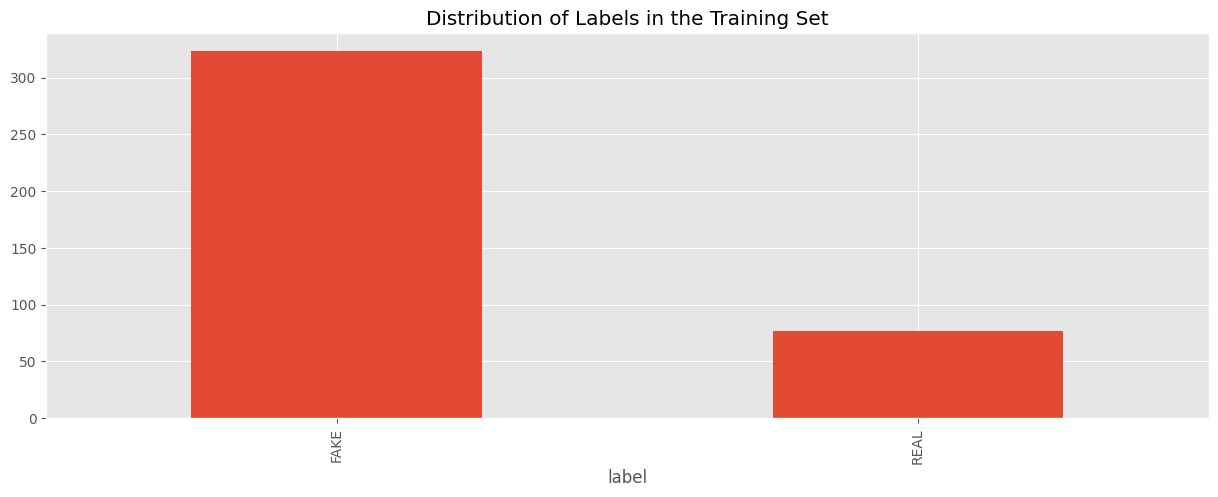

In [ ]:
train_sample_metadata.groupby('label')['label'].count().plot(figsize=(15,5), kind='bar', title='Distribution of Labels in the Training Set')

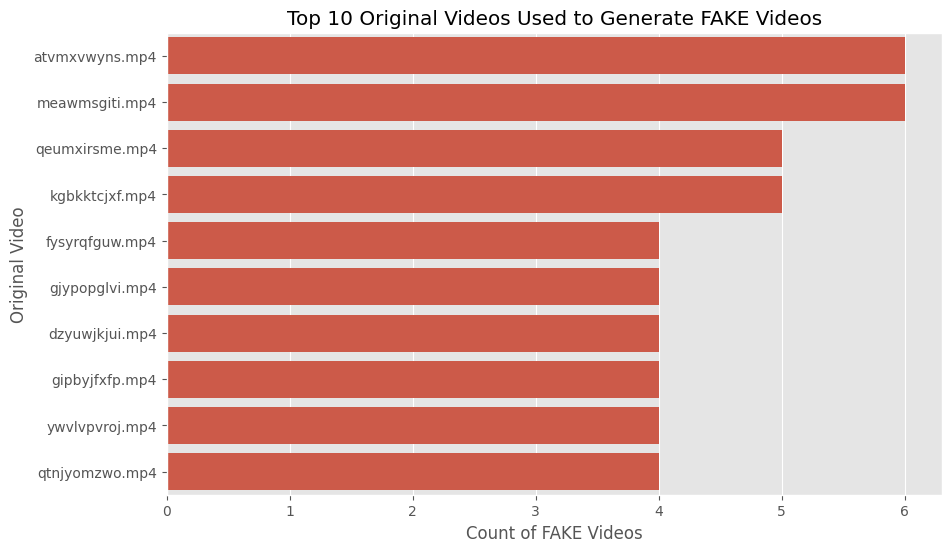

In [ ]:
fake_videos = train_sample_metadata[train_sample_metadata['label'] == 'FAKE']
plt.figure(figsize=(10, 6))
sns.countplot(data=fake_videos, y='original', order=fake_videos['original'].value_counts().index[:10])
plt.title('Top 10 Original Videos Used to Generate FAKE Videos')
plt.xlabel('Count of FAKE Videos')
plt.ylabel('Original Video')
plt.show()

In [2]:
!pip install face_recognition

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566162 sha256=cccf2838d7382393f84f6c2c99fd5747063b35532987dc3090d4755b4a4cc4f1
  Stored in directory: /root/.cache/pip/wheels/7a/eb/cf/e9eced74122b679557f597bb7c8e4c739cfcac526db1fd523d
Successfully built face-recognition-models


In [ ]:
import cv2
import os
#uses some code from https://dev.to/jumashafara/creating-image-frames-from-videos-for-deep-learning-models-2kpo
print("splitting the video into frames...")
os.chdir("/content/drive/Shareddrives/cmpe 257 Team 7/Project Code/deepfake-detection-challenge")
for vid in os.listdir("train_sample_videos"):
# Load the video
  video = cv2.VideoCapture("train_sample_videos/{}".format(vid))
  frame_count = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
  for i in range(frame_count):
    # Read a frame from the video
    ret, frame = video.read()

    # Check if the frame was successfully read
    if not ret:
        break
    vidname = vid.strip(".mp4")
    filename = "/content/drive/Shareddrives/cmpe 257 Team 7/Project Code/deepfake-detection-challenge/train_frames/{}_{}.jpg".format(vidname,i)
    cv2.imwrite(filename, frame)
  video.release()


In [3]:
from pathlib import Path
from skimage import filters
from face_recognition import face_locations

RuntimeError: Error while calling cudaGetDevice(&the_device_id) in file /root/.cache/uv/sdists-v4/pypi/dlib/19.24.2/X70kICKD8QKgWka2YcgDL/dlib-19.24.2.tar.gz/dlib/cuda/gpu_data.cpp:204. code: 35, reason: CUDA driver version is insufficient for CUDA runtime version

In [ ]:
# Set paths
input_dir = '/content/drive/Shareddrives/cmpe 257 Team 7/Project Code/deepfake-detection-challenge/train_frames'
output_dir = '/content/drive/Shareddrives/cmpe 257 Team 7/Project Code/deepfake-detection-challenge/train_frame_cleaned'

In [ ]:
# Image quality parameters
min_resolution = (64, 64)
blur_threshold = 100

In [ ]:
def check_blurriness(image):
  '''
  Checks if the image is blurry based on the variance of the Laplacian filter
  '''
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  variance = cv2.Laplacian(gray, cv2.CV_64F).var()
  return variance < blur_threshold

def check_resolution(image):
  '''
  Checks if the image has a minimum resolution
  '''
  height, width, _ = image.shape
  return width >= min_resolution[0] and height >= min_resolution[1]

def check_face_presence(image):
  '''
  Checks if the image contains a face using the face_recognition library
  '''
  rbg_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  locations = face_locations(rbg_image)
  return len(locations) > 0

In [ ]:
for img_name in os.listdir(input_dir):
  img_path = os.path.join(input_dir, img_name)
  image = cv2.imread(img_path)

  if image is None:
    print(f"Failed to load image: {img_name}")
    continue

  if check_blurriness(image):
    print(f"Blurry image: {img_name}")
    continue

  if not check_resolution(image):
    print(f"Low resolution image: {img_name}")
    continue

  if not check_face_presence(image):
    print(f"No face detected in image: {img_name}")
    continue

  output_path = os.path.join(output_dir, img_name)
  cv2.imwrite(output_dir, image)

In [ ]:
print("Code has been cleaned and output to folder")

In [ ]:
#crop images in cleaned dataset
import os
import cv2
import face_recognition
source_path = "/content/drive/MyDrive/crop_frames/train_frame_cleaned"
for im in os.listdir(source_path):
    if not (os.path.isfile("/content/drive/MyDrive/crop_frames/crop/{}".format(im))):
      iname = im.strip(".jpg")
      image = cv2.imread("{}/{}".format(source_path, im))
      face_locations = face_recognition.face_locations(image)
      if (face_locations):
        top, right, bottom, left = face_locations[0]
        face_image = image[top:bottom, left:right]
        os.chdir("/content/drive/MyDrive/crop_frames/crop")
        cv2.imwrite("{}.jpg".format(iname), face_image)
        print("{}.jpg".format(iname))